In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')
path = "/content/drive/MyDrive"
os.chdir(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
df = pd.read_parquet('crime_data_2014_2025.parquet')
df = df.drop(columns=['ID', 'Case Number','Location', 'Updated On','X Coordinate', 'Y Coordinate','IUCR','FBI Code','Date','Block', 'Description','Latitude', 'Longitude'])
location_mapping = {
    'POLICE FACILITY/VEH PARKING LOT': 'POLICE FACILITY / VEHICLE PARKING LOT',
    'VACANT LOT/LAND': 'VACANT LOT / LAND',
    'HOSPITAL BUILDING/GROUNDS': 'HOSPITAL BUILDING / GROUNDS',
    'TAVERN/LIQUOR STORE': 'TAVERN / LIQUOR STORE',
    'CHA PARKING LOT/GROUNDS': 'CHA PARKING LOT / GROUNDS',
    'SCHOOL - PUBLIC BUILDING': 'SCHOOL, PUBLIC, BUILDING',
    'SCHOOL - PUBLIC GROUNDS': 'SCHOOL, PUBLIC, GROUNDS',
    'SCHOOL - PRIVATE BUILDING': 'SCHOOL, PRIVATE, BUILDING',
    'SCHOOL - PRIVATE GROUNDS': 'SCHOOL, PRIVATE, GROUNDS',
    'HOTEL/MOTEL': 'HOTEL / MOTEL',
    'GOVERNMENT BUILDING/PROPERTY': 'GOVERNMENT BUILDING / PROPERTY',
    'NURSING HOME/RETIREMENT HOME': 'NURSING / RETIREMENT HOME',
    'SPORTS ARENA/STADIUM': 'SPORTS ARENA / STADIUM',
    'OTHER RAILROAD PROP / TRAIN DEPOT': 'OTHER RAILROAD PROPERTY / TRAIN DEPOT',
    'FACTORY/MANUFACTURING BUILDING': 'FACTORY / MANUFACTURING BUILDING',
    'HIGHWAY/EXPRESSWAY': 'HIGHWAY / EXPRESSWAY',
    'LAKEFRONT/WATERFRONT/RIVERBANK': 'LAKEFRONT / WATERFRONT / RIVERBANK',
    'MOVIE HOUSE/THEATER': 'MOVIE HOUSE / THEATER',
    'MEDICAL/DENTAL OFFICE': 'MEDICAL / DENTAL OFFICE',
    'CHA HALLWAY/STAIRWELL/ELEVATOR': 'CHA HALLWAY / STAIRWELL / ELEVATOR',
    'CTA PARKING LOT / GARAGE / OTHER PROPERTY': 'CTA GARAGE / OTHER PROPERTY',
    'COLLEGE/UNIVERSITY GROUNDS': 'COLLEGE / UNIVERSITY - GROUNDS',
    'COLLEGE/UNIVERSITY RESIDENCE HALL': 'COLLEGE / UNIVERSITY - RESIDENCE HALL',
    'VEHICLE - OTHER RIDE SHARE SERVICE (LYFT, UBER, ETC.)': 'VEHICLE - OTHER RIDE SHARE SERVICE (E.G., UBER, LYFT)',
    'PARKING LOT/GARAGE(NON.RESID.)': 'PARKING LOT / GARAGE (NON RESIDENTIAL)',
    'RESIDENCE PORCH/HALLWAY': 'RESIDENCE - PORCH / HALLWAY',
    'RESIDENTIAL YARD (FRONT/BACK)': 'RESIDENCE - YARD (FRONT / BACK)',
    'RESIDENCE-GARAGE': 'RESIDENCE - GARAGE',
}

df['Location Description'] = df['Location Description'].replace(location_mapping)

In [ ]:
loc_stats = (df.groupby('Location Description')
               .agg(count=('Arrest','count'),
                    arrest_rate=('Arrest','mean'))
               .sort_values('count', ascending=False))

top30_locs = loc_stats.head(30).index.tolist()
df['Location Description'] = df['Location Description'].apply(lambda x: x if x in top30_locs else 'OTHER')

In [ ]:
df['is_weekend'] = df['Weekday'].isin([5, 6]).astype(int)
df['is_night']   = ((df['Hour'] >= 22) | (df['Hour'] <= 6)).astype(int)

In [ ]:
# encode
df['Domestic'] = df['Domestic'].astype(int)
df['Arrest']   = df['Arrest'].astype(int)

df['hour_sin']    = np.sin(2 * np.pi * df['Hour'] / 24)
df['hour_cos']    = np.cos(2 * np.pi * df['Hour'] / 24)
df['month_sin']   = np.sin(2 * np.pi * df['Month'] / 12)
df['month_cos']   = np.cos(2 * np.pi * df['Month'] / 12)
df['weekday_sin'] = np.sin(2 * np.pi * df['Weekday'] / 7)
df['weekday_cos'] = np.cos(2 * np.pi * df['Weekday'] / 7)

df_encoded = pd.get_dummies(
    df,
    columns=['Primary Type', 'Location Description', 'District'],
    drop_first=False,
    dtype=int)

In [ ]:
drop_original = ['Hour', 'Month', 'Weekday','Beat', 'Ward', 'Community Area']
df_encoded = df_encoded.drop(columns=[c for c in drop_original if c in df_encoded.columns])

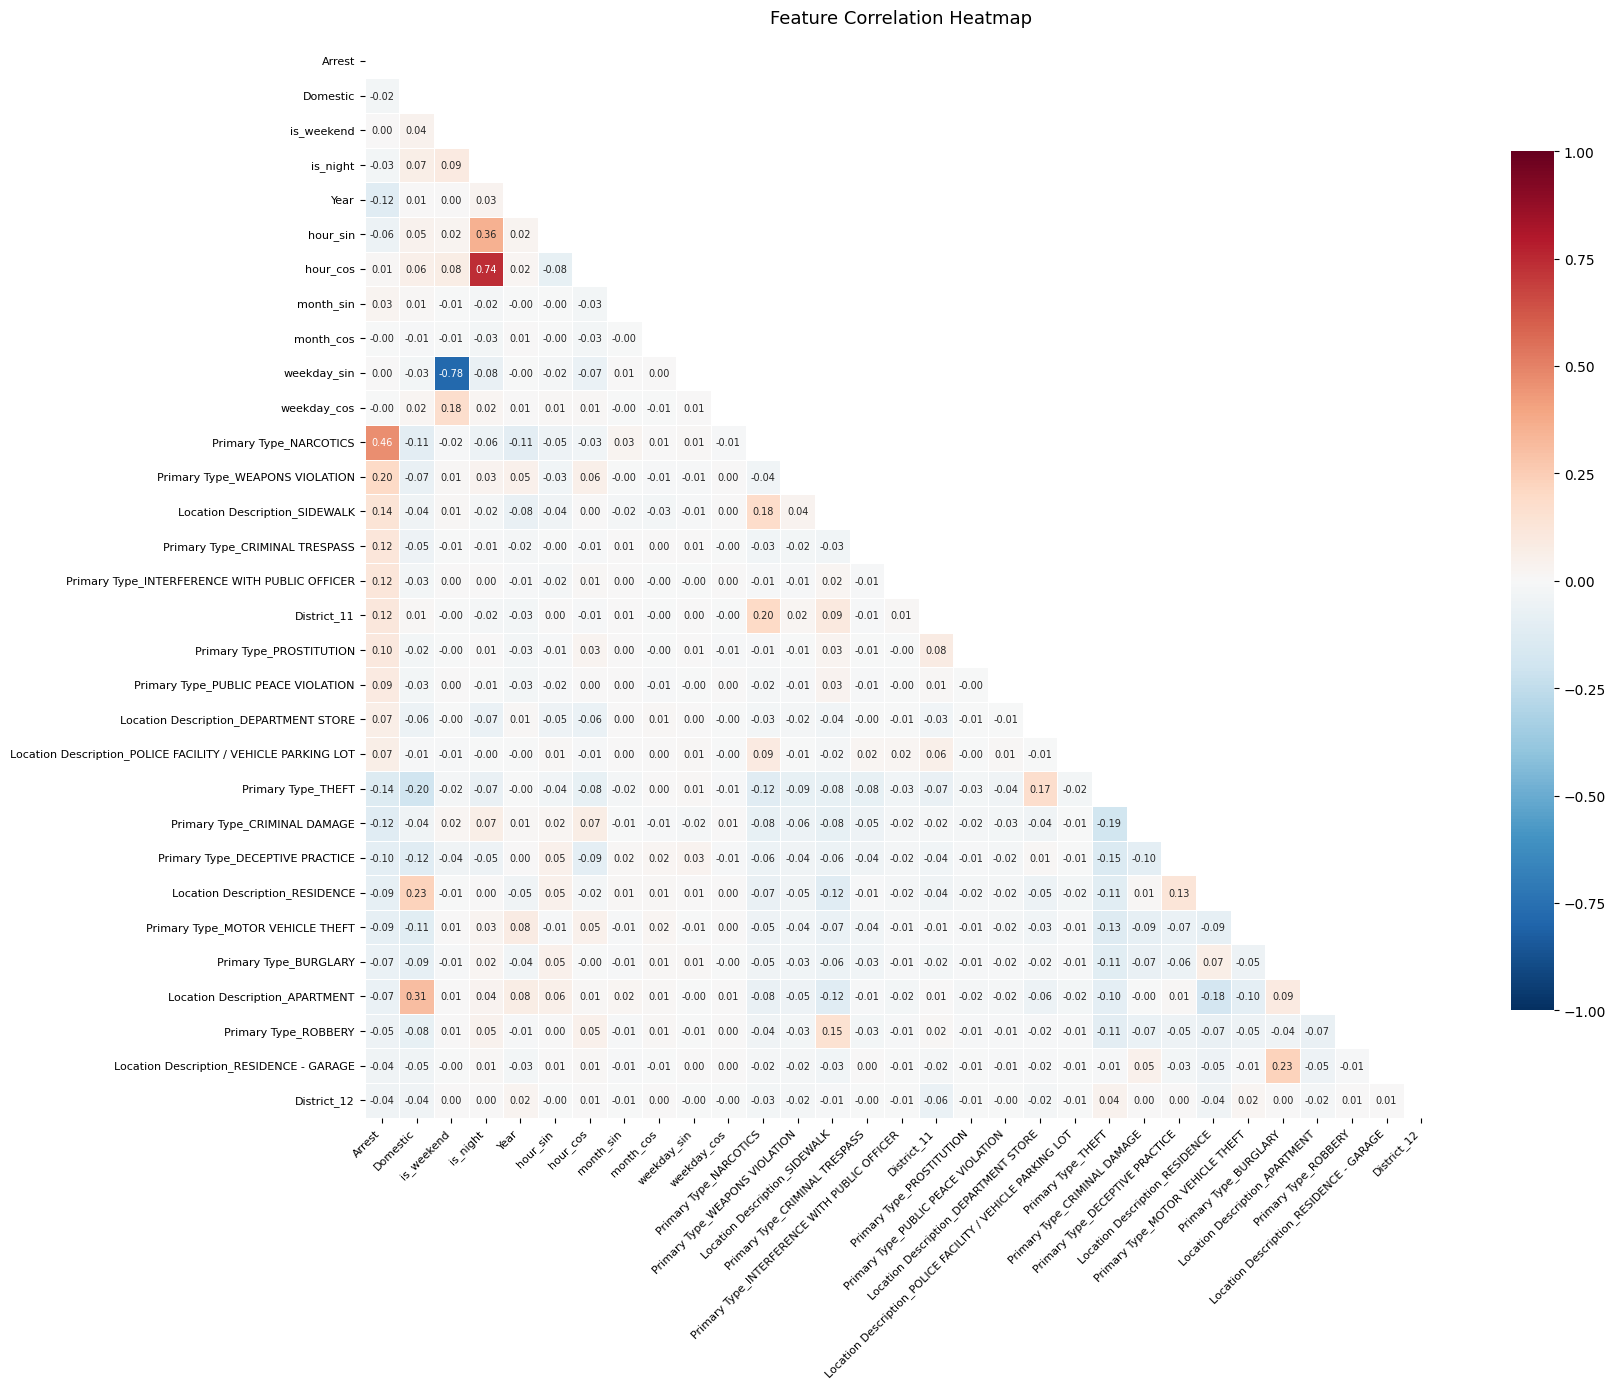


Top15 positive
Primary Type_NARCOTICS                                        0.4635
Primary Type_WEAPONS VIOLATION                                0.1984
Location Description_SIDEWALK                                 0.1365
Primary Type_CRIMINAL TRESPASS                                0.1216
Primary Type_INTERFERENCE WITH PUBLIC OFFICER                 0.1172
District_11                                                   0.1164
Primary Type_PROSTITUTION                                     0.1017
Primary Type_PUBLIC PEACE VIOLATION                           0.0866
Location Description_DEPARTMENT STORE                         0.0675
Location Description_POLICE FACILITY / VEHICLE PARKING LOT    0.0659
Primary Type_LIQUOR LAW VIOLATION                             0.0617
Location Description_GROCERY FOOD STORE                       0.0566
Primary Type_CONCEALED CARRY LICENSE VIOLATION                0.0477
Location Description_ALLEY                                    0.0477
Primary Type_GAMBL

In [ ]:
# Correlation Heatmap
numeric_cols = [
    'Arrest', 'Domestic', 'is_weekend', 'is_night', 'Year',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'weekday_sin', 'weekday_cos'
]

ohe_cols = [c for c in df_encoded.columns if c not in numeric_cols and c != 'Arrest']
ohe_corr = df_encoded[ohe_cols + ['Arrest']].corr()['Arrest'].drop('Arrest')
top10_pos = ohe_corr.nlargest(10).index.tolist()
top10_neg = ohe_corr.nsmallest(10).index.tolist()

heatmap_cols = numeric_cols + top10_pos + top10_neg

corr_matrix = df_encoded[heatmap_cols].corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 7},
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Heatmap',fontsize=13, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop15 positive")
all_corr = df_encoded.corr()['Arrest'].drop('Arrest').sort_values(ascending=False)
print(all_corr.head(15).round(4))
print("\nTop15 negative")
print(all_corr.tail(15).round(4))

In [ ]:
# VIF
vif_cols = ['Year', 'Domestic', 'is_weekend', 'is_night',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'weekday_sin', 'weekday_cos']
vif_data = df_encoded[vif_cols].dropna()

vif_result = pd.DataFrame({
    'Feature': vif_cols,
    'VIF': [variance_inflation_factor(vif_data.values, i)
            for i in range(len(vif_cols))]
}).sort_values('VIF', ascending=False)
print(vif_result.round(4))

       Feature     VIF
3     is_night  4.9849
0         Year  4.7843
2   is_weekend  3.9661
5     hour_cos  3.1727
8  weekday_sin  2.7346
4     hour_sin  1.7710
1     Domestic  1.2461
9  weekday_cos  1.0973
6    month_sin  1.0041
7    month_cos  1.0038


In [ ]:
df_encoded = df_encoded.drop(columns=['District_-1', 'is_night'])

In [ ]:
# save
df_encoded.to_parquet('chicago_features_final.parquet', index=False)
train_mask = df_encoded['Year'] < 2025
test_mask  = df_encoded['Year'] >= 2025

df_encoded[train_mask].to_parquet('chicago_train.parquet', index=False)
df_encoded[test_mask].to_parquet('chicago_test.parquet', index=False)